In [1]:
from magnonics import *
from lswt import *

In [2]:
lat_new, basis_new, hamil_new = Initialize.from_csv('setup.csv')

transl_vects = ['[1,0,0]', '[0,a,0]', '[0,0,1]']
spins = [{'sublattice': 1.0, 'basis vector': '[0,0,0]', 'ground state direction': '[0,0,1]', 'spin length': 'S1', 'gyromagnetic matrix': '[[g, 0, 0], [0, g, 0], [0, 0, g]]'}]
interactions = [{'reference sublat': 1.0, 'neighbor sublat': 1.0, 'difference vector': '[0,1,0]', 'interaction matrix': '[[J,0,0],[0,J,0],[0,0,J]]'}, {'reference sublat': 1.0, 'neighbor sublat': 1.0, 'difference vector': '[0,0,0]', 'interaction matrix': '[[0,0,0],[0,0,0],[0,0,A]]'}, {'reference sublat': 1.0, 'neighbor sublat': 1.0, 'difference vector': '[0,1,0]', 'interaction matrix': '[[0,Dz,0],[-Dz,0,0],[0,0,0]]'}]
params = {'a': '1', 'S1': '1', 'J': '-1', 'A': '-1', 'Dz': '0', 'g': '1', 'B': '(0,0,0)'}


In [3]:
hamil_old, lat_old, basis_old = InputProcessing.initialize_from_txtfile("setup.txt")

lat_lines=['[1, 0, 0]', '[0, a, 0]', '[0, 0, 1]', '1\t\t|\t[0, 0, 0]\t|\tS1\t\t|\t[[g, 0, 0], [0, g, 0], [0, 0, g]]\t|\t[0, 0, 1]']
int_lines=['1\t\t|\t1\t\t|\t[0, 1, 0]\t\t|\t[[J, 0, 0], [0, J, 0], [0, 0, J]]', '1\t\t|\t1\t\t|\t[0, 0, 0]\t\t|\t[[0, 0, 0], [0, 0, 0], [0, 0, A]]', '1\t\t|\t1\t\t|\t[0, 1, 0]\t\t|\t[[0, Dz, 0], [-Dz, 0, 0], [0, 0, 0]]']
params={'a': 1.0, 'g': 1.0, 'J': -1.0, 'A': -1.0, 'Dz': 0.0, 'S1': 1.0, 'Bx': 0.0, 'By': 0.0, 'Bz': 0.0}
basisvect = Matrix([[0], [0], [0]]), spinlen = S1, grdstatedir = Matrix([[0], [0], [1]])


In [4]:
hamil_new.lat.vects ;

In [5]:
hamil_old.lat.vects ;

In [6]:
print(hamil_new.lat.vects == hamil_old.lat.vects)

True


In [40]:
hamil_new.lat.rcpr_vects ;

In [8]:
hamil_old.lat.rcpr_vects ;

In [9]:
print(hamil_new.lat.rcpr_vects == hamil_old.lat.rcpr_vects)

True


In [10]:
hamil_new.lat.num_rcpr_vects ;

In [11]:
hamil_old.lat.num_rcpr_vects ;

In [12]:
print(hamil_new.lat.num_rcpr_vects == hamil_old.lat.num_rcpr_vects)

[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]


In [13]:
hamil_new.basis.atoms[0].interactions[0][0].intmat ;

In [14]:
hamil_old.mainbasis.atoms[0].interactions[0][0].intermatr ;

In [15]:
print(hamil_new.basis.atoms[0].interactions[0][0].intmat == hamil_old.mainbasis.atoms[0].interactions[0][0].intermatr)

True


In [16]:
hamil_new.params

{'a': '1',
 'S1': '1',
 'J': '-1',
 'A': '-1',
 'Dz': '0',
 'g': '1',
 'B': '(0,0,0)'}

In [17]:
hamil_old.num_parameters

{'a': 1.0,
 'g': 1.0,
 'J': -1.0,
 'A': -1.0,
 'Dz': 0.0,
 'S1': 1.0,
 'Bx': 0.0,
 'By': 0.0,
 'Bz': 0.0}

In [18]:
hamil_new.HP_trafo(symbolic=False, simplify=True)

<bound method LinearSpinWave.HP_numeric of <magnonics.LinearSpinWave object at 0x0000011F165D8980>>

In [19]:
hamil_old.holstein_primakoff(symbolic=False, simplify=True)

holstein_primakoff called, symbolic=False


<function lswt.LinearSpinWave.holstein_primakoff.<locals>.hmatr(*k)>

In [20]:
hamil_new.bihamil

<bound method LinearSpinWave.HP_numeric of <magnonics.LinearSpinWave object at 0x0000011F165D8980>>

In [21]:
hamil_old.bilinear_hamil

<function lswt.LinearSpinWave.holstein_primakoff.<locals>.hmatr(*k)>

In [22]:
# sp.simplify(hamil_new.bihamil - hamil_old.bilinear_hamil)

In [23]:
# hamil_new.bihamil.equals(hamil_old.bilinear_hamil)

In [24]:
hamil_new.parameterize_hamil()

Automatically finding sufficient chemical potential...
[[1.41421356-0.j 0.        -0.j]
 [0.        -0.j 1.41421356-0.j]]
[[1.41421356+0.j 0.        +0.j]
 [0.        +0.j 1.41421356+0.j]]
ldiag=
[-2.  2.], 
 umat=
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
order=[1 0]
ordered ldiag=
[ 2. -2.], 
 ordered umat=
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
full L=
[[ 2.  0.]
 [ 0. -2.]], 
 Emat=
[[2. 0.]
 [0. 2.]]
sqrt of Emat=
[[1.41421356 0.        ]
 [0.         1.41421356]], 
 eigenvects T^-1=
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Using 0 as chemical potential.


0

In [25]:
hamil_old.parameterize_hamil()

Automatically finding chemical potential ...
[[1.41421356-0.j 0.        -0.j]
 [0.        -0.j 1.41421356-0.j]]
[[1.41421356+0.j 0.        +0.j]
 [0.        +0.j 1.41421356+0.j]]
ldiag=
[-2.  2.], 
 umat=
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
order = [1, 0]
ordered ldiag=
[ 2. -2.], 
 ordered umat=
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
full L=
[[ 2.  0.]
 [ 0. -2.]], 
 Emat=
[[2. 0.]
 [0. 2.]]
sqrt of Emat=
[[1.41421356 0.        ]
 [0.         1.41421356]], 
 eigenvects T^-1=
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Using 0 as chemical potential.


0

In [26]:
hamil_new.debug1

In [27]:
hamil_old.debug1

In [28]:
# hamil_new.debug1.equals(hamil_old.debug1)

In [29]:
print(hamil_new.debug2)

None


In [30]:
print(hamil_old.debug2)

None


In [31]:
# hamil_new.debug2(0,0,0) == hamil_old.debug2(0,0,0)
type(hamil_new.debug2) == type(hamil_old.debug2)

True

In [32]:
hamil_new.debug3

<bound method LinearSpinWave.HP_numeric of <magnonics.LinearSpinWave object at 0x0000011F165D8980>>

In [33]:
hamil_old.debug3

<function lswt.LinearSpinWave.holstein_primakoff.<locals>.hmatr(*k)>

In [34]:
hamil_new.debug3(0,0,0) == hamil_old.debug3(0,0,0)

array([[ True,  True],
       [ True,  True]])

In [35]:
hamil_new.debug4

<function magnonics.LinearSpinWave.parameterize_hamil.<locals>.add_chempot.<locals>.<lambda>(*k)>

In [36]:
hamil_old.debug4

<function lswt.LinearSpinWave.parameterize_hamil.<locals>.add_chem_potential.<locals>.<lambda>(*k)>

In [37]:
hamil_new.debug4(0,0,0) == hamil_old.debug4(0,0,0)

array([[ True,  True],
       [ True,  True]])

[[2.44948974-0.j 0.        -0.j]
 [0.        -0.j 2.44948974-0.j]]
[[2.44948974+0.j 0.        +0.j]
 [0.        +0.j 2.44948974+0.j]]
ldiag=
[-6.  6.], 
 umat=
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
order=[1 0]
ordered ldiag=
[ 6. -6.], 
 ordered umat=
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
full L=
[[ 6.  0.]
 [ 0. -6.]], 
 Emat=
[[6. 0.]
 [0. 6.]]
sqrt of Emat=
[[2.44948974 0.        ]
 [0.         2.44948974]], 
 eigenvects T^-1=
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
[[2.44866767-0.j 0.        -0.j]
 [0.        -0.j 2.44866767-0.j]]
[[2.44866767+0.j 0.        +0.j]
 [0.        +0.j 2.44866767+0.j]]
ldiag=
[-5.99597335  5.99597335], 
 umat=
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
order=[1 0]
ordered ldiag=
[ 5.99597335 -5.99597335], 
 ordered umat=
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
full L=
[[ 5.99597335  0.        ]
 [ 0.         -5.99597335]], 
 Emat=
[[5.99597335 0.        ]
 [0.         5.99597335]]
sqrt of Emat=
[[2.44866767 0.        ]
 [0.         2.44866767]], 
 eigenvects T^-1=
[[1.+0.j 0.+0

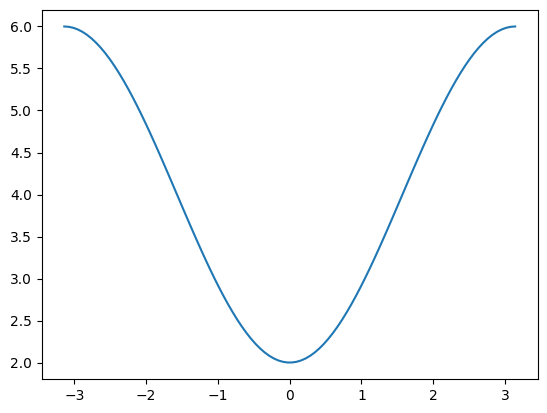

In [38]:
import numpy as np
import matplotlib.pyplot as plt
vec_y = lat_new.num_rcpr_vects[1,1]
k_values = np.linspace(-vec_y/2,vec_y/2,100)
energies = []

# hamil_new.update_num_parameters(dict(Dz = 1.5))
hamil_new.parameterize_hamil()

for n in k_values:
    E, EV = hamil_new.Bogoliubov_trafo(0,n,0)
    energies.append(E[0])

plt.plot(k_values, energies)
plt.show()